In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
from matplotlib.patches import Patch, Polygon

%matplotlib inline

In [2]:
import os
import sys

os.environ["ROOT"] = f"/home/565/{os.environ['USER']}/trop-wx-sys-characs"

module_path = os.path.abspath(os.path.join(os.environ["ROOT"]))

sys.path.insert(0, module_path)

In [3]:
import filter_mode

In [4]:
ds = xr.open_dataset("/scratch/k10/mr4682/data/ISCCP/txuptp/txuptp.clim.and.anom.1984-2016.nc")

olr = ds["txuptp_anom"].sel(latitude=slice(-20.5, 20.5))

In [5]:
time = olr["time"]
latitude = olr["latitude"]
longitude = olr["longitude"]

In [6]:
%%time

olr = olr.fillna(0.0)
olr

CPU times: user 3.51 s, sys: 23.8 s, total: 27.3 s
Wall time: 2min 17s


<xarray.DataArray 'txuptp_anom' (time: 96432, latitude: 42, longitude: 360)> Size: 12GB
array([[[ -1.42425078,  -2.20860727,  -4.03287157, ...,   5.76368667,
           2.94631911,   5.68792347],
        [  4.16875796, -16.38529112, -27.5256902 , ...,   3.65541678,
           0.48785209,   6.1214242 ],
        [-12.61675821, -35.74695962, -28.60462336, ...,   1.28484221,
           6.71654338,  -7.14880722],
        ...,
        [ 16.03435038,  17.64984344,  14.41761843, ...,  11.52654534,
          12.03920432,  29.09343104],
        [ 21.88077797,  13.06504162,  13.44365787, ...,  14.84599091,
          14.71733753,  23.67862045],
        [ 16.49657015,  15.62489798,  12.11098308, ...,   7.03608809,
           9.94335485,  12.32707114]],

       [[ -1.84696856,   2.51265178,  -0.97360698, ...,   6.96943298,
           5.57067584,   4.2711014 ],
        [  5.24939153, -19.68240243, -29.1274524 , ...,   5.94347955,
           5.51755411,  11.43726799],
        [ -9.67737857, -41.13186402, -26.18397459, ...,  -1.57105113,
           1.69590821,  -6.67269355],
...
        [ 10.6155605 ,  10.12742364,   5.62919006, ...,   5.40513925,
          12.12201146,  11.21646977],
        [ 14.02482001,  12.32101377,   9.6500002 , ...,  -4.91657696,
          -2.75527746,   9.81764938],
        [ 12.44329481,   9.678904  ,  10.50544123, ...,  -3.66879821,
           1.21540516,   4.37493604]],

       [[  3.75956869,  -3.65046415, -10.26976538, ...,   7.41076561,
           8.8591104 ,   5.61380832],
        [ -5.27164832,  -4.58289674,  -7.69286484, ...,   4.07489554,
           0.75012685,  -4.47036274],
        [ -4.87962524, -10.56694815,  -9.43468739, ...,  -2.05236814,
          -4.28816195,  -4.82705062],
        ...,
        [ 12.41420017,  10.30996213,   7.78974882, ...,  10.11864286,
          13.89562998,  11.28010023],
        [ 11.59830663,  13.66987693,  11.61886019, ...,  -1.15361151,
           7.36061175,  10.05034356],
        [ 10.04658136,   5.38314209,   7.90092264, ...,  -3.05336796,
          -0.68661958,   4.22296701]]])
Coordinates:
  * latitude   (latitude) float32 168B -20.5 -19.5 -18.5 ... 18.5 19.5 20.5
  * longitude  (longitude) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * time       (time) datetime64[ns] 771kB 1984-01-01 ... 2016-12-31T21:00:00
Attributes:
    units:      Wm-2
    long_name:  toa_outgoing_longtwave_flux_all_sky
    type:       short: convert to Real*4 = Short_value / scale_factor

In [7]:
%%time

pSym, pAsy, pBG, frq, k = filter_mode.stsa.stsaTLL(olr.values, latitude.values, spd=8, nDayWin=96, nDayOvl=65, divideByBG=False, returnBG=True)

CPU times: user 3min, sys: 1min 36s, total: 4min 37s
Wall time: 4min 38s


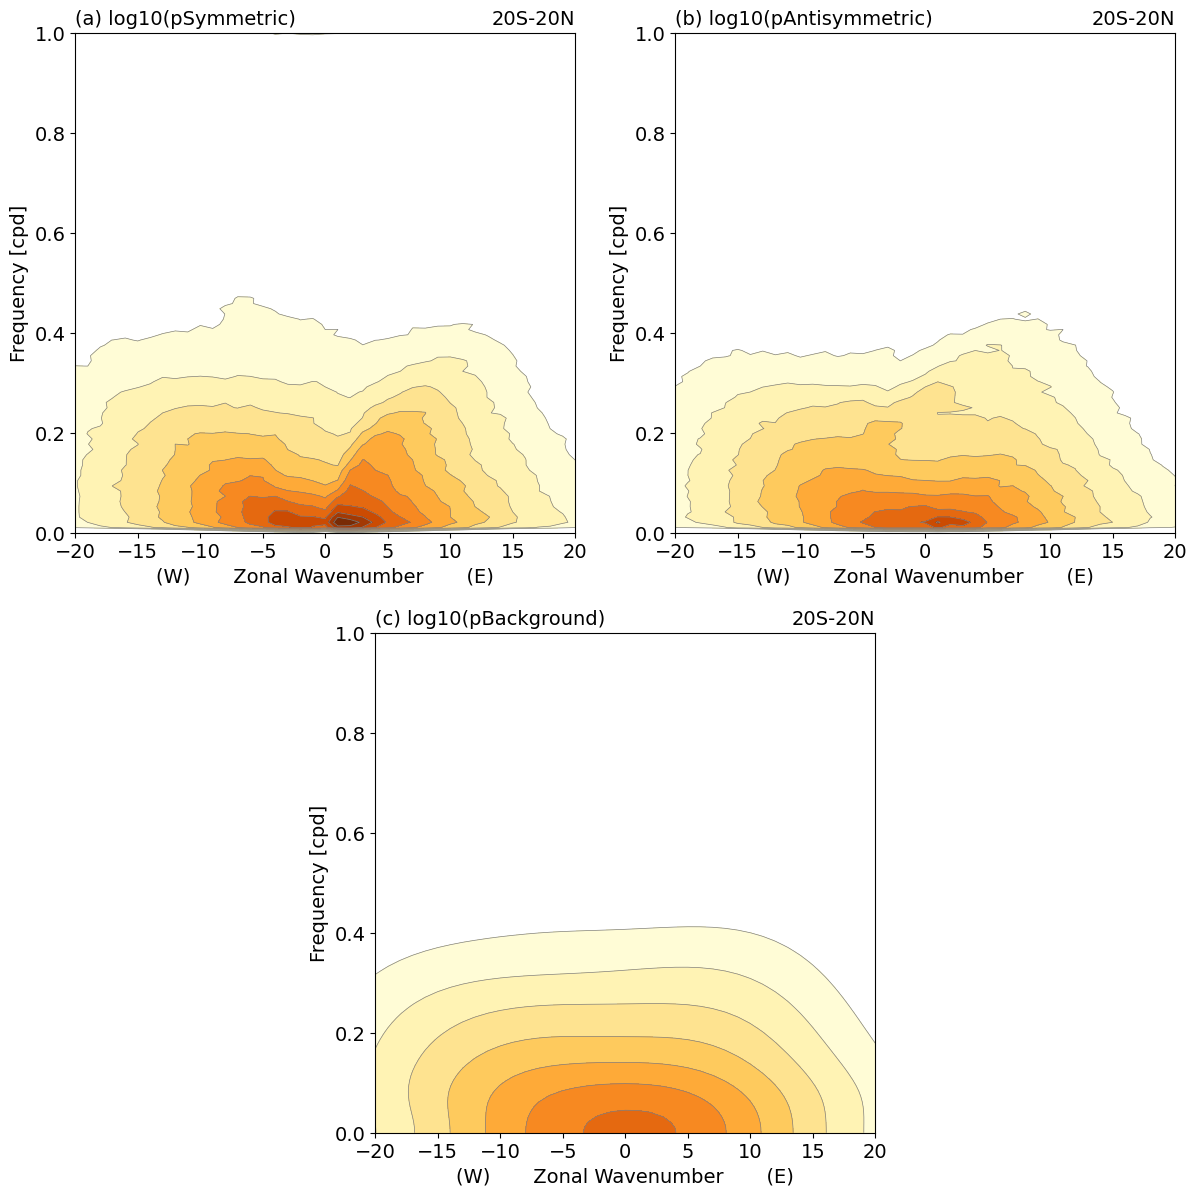

In [8]:
figx = 13.0
figy = 14.0

fig = plt.figure(figsize=(figx, figy))

levels = np.arange(0.0, 2.2, 0.2)
cmap = "YlOrBr"
fontsize = 14.0

ax1 = fig.add_axes([1.0 / figx, 8.0 / figy, 5.0 / figx, 5.0 / figy])
plot1 = ax1.contourf(k, frq, np.log10(pSym), levels=levels, cmap=cmap, extend="max")
plot1_contour = ax1.contour(k, frq, np.log10(pSym), levels=levels, colors="grey", linewidths=0.5)

ax1.set_title("(a) log10(pSymmetric)", loc="left", fontsize=fontsize)
ax1.set_title("20S-20N", loc="right", fontsize=fontsize)
ax1.set_xlim(-20.0, 20.0)
ax1.set_ylim(0.0, 1.0)
ax1.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax1.set_yticks(np.arange(0.0, 1.2, 0.2))
ax1.tick_params(labelsize=fontsize)
ax1.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax1.set_ylabel("Frequency [cpd]", fontsize=fontsize)

ax2 = fig.add_axes([7.0 / figx, 8.0 / figy, 5.0 / figx, 5.0 / figy])
plot2 = ax2.contourf(k, frq, np.log10(pAsy), levels=levels, cmap=cmap, extend="max")
plot2_contour = ax2.contour(k, frq, np.log10(pAsy), levels=levels, colors="grey", linewidths=0.5)

ax2.set_title("(b) log10(pAntisymmetric)", loc="left", fontsize=fontsize)
ax2.set_title("20S-20N", loc="right", fontsize=fontsize)
ax2.set_xlim(-20.0, 20.0)
ax2.set_ylim(0.0, 1.0)
ax2.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax2.set_yticks(np.arange(0.0, 1.2, 0.2))
ax2.tick_params(labelsize=fontsize)
ax2.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax2.set_ylabel("Frequency [cpd]", fontsize=fontsize)

ax3 = fig.add_axes([4.0 / figx, 2.0 / figy, 5.0 / figx, 5.0 / figy])
plot3 = ax3.contourf(k, frq, np.log10(pBG), levels=levels, cmap=cmap, extend="max")
plot3_contour = ax3.contour(k, frq, np.log10(pBG), levels=levels, colors="grey", linewidths=0.5)

ax3.set_title("(c) log10(pBackground)", loc="left", fontsize=fontsize)
ax3.set_title("20S-20N", loc="right", fontsize=fontsize)
ax3.set_xlim(-20.0, 20.0)
ax3.set_ylim(0.0, 1.0)
ax3.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax3.set_yticks(np.arange(0.0, 1.2, 0.2))
ax3.tick_params(labelsize=fontsize)
ax3.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax3.set_ylabel("Frequency [cpd]", fontsize=fontsize)

fig.savefig(fname="/home/565/mr4682/trop-wx-sys-characs/plots/stsa_decomposed_with_background_isccp_olr.png", bbox_inches="tight")

plt.show()

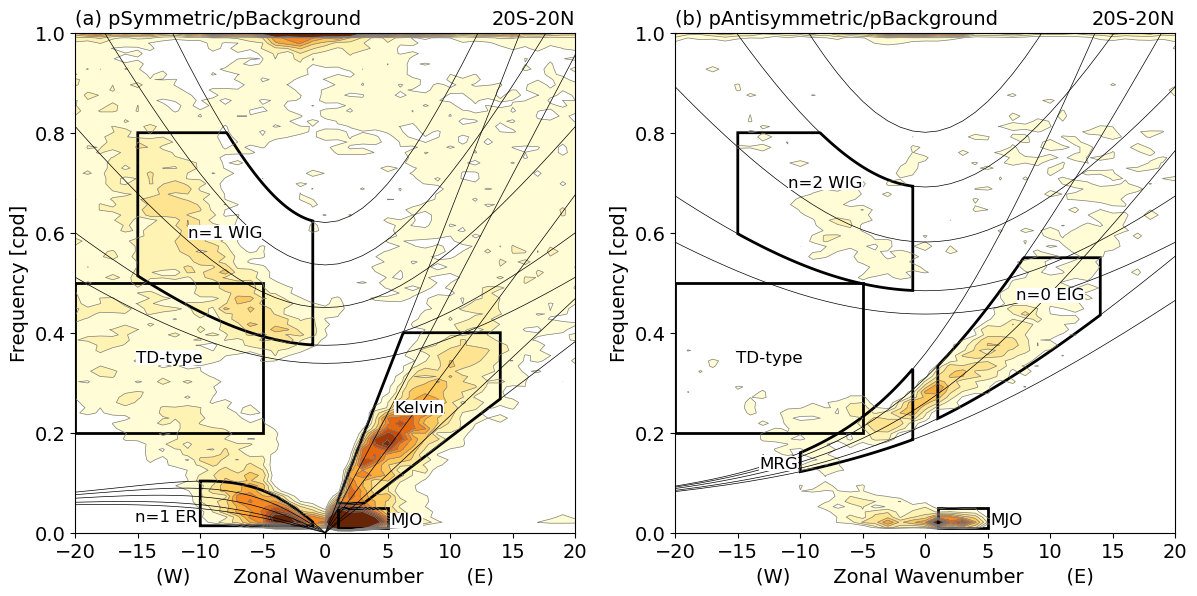

In [9]:
frq_Kelvin_8 = filter_mode.stsa.calc_frq_dispersion(k, h=8, wave="Kelvin")
frq_Kelvin_12 = filter_mode.stsa.calc_frq_dispersion(k, h=12, wave="Kelvin")
frq_Kelvin_25 = filter_mode.stsa.calc_frq_dispersion(k, h=25, wave="Kelvin")
frq_Kelvin_50 = filter_mode.stsa.calc_frq_dispersion(k, h=50, wave="Kelvin")
frq_Kelvin_90 = filter_mode.stsa.calc_frq_dispersion(k, h=90, wave="Kelvin")

frq_ER_8 = filter_mode.stsa.calc_frq_dispersion(k, h=8, wave="ER")
frq_ER_12 = filter_mode.stsa.calc_frq_dispersion(k, h=12, wave="ER")
frq_ER_25 = filter_mode.stsa.calc_frq_dispersion(k, h=25, wave="ER")
frq_ER_50 = filter_mode.stsa.calc_frq_dispersion(k, h=50, wave="ER")
frq_ER_90 = filter_mode.stsa.calc_frq_dispersion(k, h=90, wave="ER")

frq_IG1_8 = filter_mode.stsa.calc_frq_dispersion(k, h=8, wave="IG1")
frq_IG1_12 = filter_mode.stsa.calc_frq_dispersion(k, h=12, wave="IG1")
frq_IG1_25 = filter_mode.stsa.calc_frq_dispersion(k, h=25, wave="IG1")
frq_IG1_50 = filter_mode.stsa.calc_frq_dispersion(k, h=50, wave="IG1")
frq_IG1_90 = filter_mode.stsa.calc_frq_dispersion(k, h=90, wave="IG1")

frq_MRG_8 = filter_mode.stsa.calc_frq_dispersion(k, h=8, wave="MRG")
frq_MRG_12 = filter_mode.stsa.calc_frq_dispersion(k, h=12, wave="MRG")
frq_MRG_25 = filter_mode.stsa.calc_frq_dispersion(k, h=25, wave="MRG")
frq_MRG_50 = filter_mode.stsa.calc_frq_dispersion(k, h=50, wave="MRG")
frq_MRG_90 = filter_mode.stsa.calc_frq_dispersion(k, h=90, wave="MRG")

frq_IG2_8 = filter_mode.stsa.calc_frq_dispersion(k, h=8, wave="IG2")
frq_IG2_12 = filter_mode.stsa.calc_frq_dispersion(k, h=12, wave="IG2")
frq_IG2_25 = filter_mode.stsa.calc_frq_dispersion(k, h=25, wave="IG2")
frq_IG2_50 = filter_mode.stsa.calc_frq_dispersion(k, h=50, wave="IG2")
frq_IG2_90 = filter_mode.stsa.calc_frq_dispersion(k, h=90, wave="IG2")

figx = 13.0
figy = 8.0

fig = plt.figure(figsize=(figx, figy))

levels = np.arange(1.0, 2.1, 0.1)
cmap = "YlOrBr"
lw = 0.5
lw_poly = 2.0
fontsize = 14.0

poly_MJO1 = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=5.0, frq_min=1.0 / 100.0, frq_max=1.0 / 20.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw_poly)
poly_Kelvin = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=14.0, frq_min=1.0 / 17.0, frq_max=1.0 / 2.5, h_min=8.0, h_max=90.0, wave="Kelvin"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_ER = Polygon(filter_mode.stsa.calc_wave_region(k_min=-10.0, k_max=-1.0, frq_min=1.0 / 72.0, frq_max=1.0 / 9.0, h_min=None, h_max=90.0, wave="ER"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_MRG = Polygon(filter_mode.stsa.calc_wave_region(k_min=-10.0, k_max=-1.0, frq_min=1.0 / 10.0, frq_max=1.0 / 3.0, h_min=8.0, h_max=90.0, wave="MRG"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_EIG = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=14.0, frq_min=1.0 / 5.0, frq_max=0.55, h_min=12.0, h_max=50.0, wave="MRG"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_WIG1 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-15.0, k_max=-1.0, frq_min=1.0 / 3.0, frq_max=0.8, h_min=12.0, h_max=90.0, wave="IG1"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_WIG2 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-15.0, k_max=-1.0, frq_min=1.0 / 3.0, frq_max=0.8, h_min=12.0, h_max=50.0, wave="IG2"), closed=True, ec="black", fc="none", lw=lw_poly)
poly_TD1 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=-5.0, frq_min=1.0 / 5.0, frq_max=1.0 / 2.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw_poly)

ax1 = fig.add_axes([1.0 / figx, 2.0 / figy, 5.0 / figx, 5.0 / figy])
plot1 = ax1.contourf(k, frq, pSym / pBG, levels=levels, cmap=cmap, extend="max")
plot1_contour = ax1.contour(k, frq, pSym / pBG, levels=levels, colors="grey", linewidths=0.5)

plot_Kelvin_8 = ax1.plot(k, frq_Kelvin_8, c="k", lw=lw)
plot_Kelvin_12 = ax1.plot(k, frq_Kelvin_12, c="k", lw=lw)
plot_Kelvin_25 = ax1.plot(k, frq_Kelvin_25, c="k", lw=lw)
plot_Kelvin_50 = ax1.plot(k, frq_Kelvin_50, c="k", lw=lw)
plot_Kelvin_90 = ax1.plot(k, frq_Kelvin_90, c="k", lw=lw)

plot_ER_8 = ax1.plot(k, frq_ER_8, c="k", lw=lw)
plot_ER_12 = ax1.plot(k, frq_ER_12, c="k", lw=lw)
plot_ER_25 = ax1.plot(k, frq_ER_25, c="k", lw=lw)
plot_ER_50 = ax1.plot(k, frq_ER_50, c="k", lw=lw)
plot_ER_90 = ax1.plot(k, frq_ER_90, c="k", lw=lw)

plot_IG1_8 = ax1.plot(k, frq_IG1_8, c="k", lw=lw)
plot_IG1_12 = ax1.plot(k, frq_IG1_12, c="k", lw=lw)
plot_IG1_25 = ax1.plot(k, frq_IG1_25, c="k", lw=lw)
plot_IG1_50 = ax1.plot(k, frq_IG1_50, c="k", lw=lw)
plot_IG1_90 = ax1.plot(k, frq_IG1_90, c="k", lw=lw)

ax1.add_patch(poly_MJO1)
ax1.add_patch(poly_Kelvin)
ax1.add_patch(poly_ER)
ax1.add_patch(poly_WIG1)
ax1.add_patch(poly_TD1)

ax1.text(5.2, 1.0 / 40.0, "MJO", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="left", va="center")
ax1.text(-10.2, 2.0 / 63.0, "n=1 ER", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="right", va="center")
ax1.text(7.5, 0.25, "Kelvin", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="center", va="center")
ax1.text(-12.5, 0.35, "TD-type", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="center", va="center")
ax1.text(-11.0, 0.6, "n=1 WIG", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="left", va="center")

ax1.set_title("(a) pSymmetric/pBackground", loc="left", fontsize=fontsize)
ax1.set_title("20S-20N", loc="right", fontsize=fontsize)
ax1.set_xlim(-20.0, 20.0)
ax1.set_ylim(0.0, 1.0)
ax1.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax1.set_yticks(np.arange(0.0, 1.2, 0.2))
ax1.tick_params(labelsize=fontsize)
ax1.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax1.set_ylabel("Frequency [cpd]", fontsize=fontsize)

ax2 = fig.add_axes([7.0 / figx, 2.0 / figy, 5.0 / figx, 5.0 / figy])
plot2 = ax2.contourf(k, frq, pAsy / pBG, levels=levels, cmap=cmap, extend="max")
plot2_contour = ax2.contour(k, frq, pAsy / pBG, levels=levels, colors="grey", linewidths=0.5)

plot_MRG_8 = ax2.plot(k, frq_MRG_8, c="k", lw=lw)
plot_MRG_12 = ax2.plot(k, frq_MRG_12, c="k", lw=lw)
plot_MRG_25 = ax2.plot(k, frq_MRG_25, c="k", lw=lw)
plot_MRG_50 = ax2.plot(k, frq_MRG_50, c="k", lw=lw)
plot_MRG_90 = ax2.plot(k, frq_MRG_90, c="k", lw=lw)

plot_IG2_8 = ax2.plot(k, frq_IG2_8, c="k", lw=lw)
plot_IG2_12 = ax2.plot(k, frq_IG2_12, c="k", lw=lw)
plot_IG2_25 = ax2.plot(k, frq_IG2_25, c="k", lw=lw)
plot_IG2_50 = ax2.plot(k, frq_IG2_50, c="k", lw=lw)
plot_IG2_90 = ax2.plot(k, frq_IG2_90, c="k", lw=lw)

poly_MJO2 = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=5.0, frq_min=1.0 / 100.0, frq_max=1.0 / 20.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw_poly)
poly_TD2 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=-5.0, frq_min=1.0 / 5.0, frq_max=1.0 / 2.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw_poly)

ax2.add_patch(poly_MJO2)
ax2.add_patch(poly_MRG)
ax2.add_patch(poly_EIG)
ax2.add_patch(poly_WIG2)
ax2.add_patch(poly_TD2)

ax2.text(5.2, 1.0 / 40.0, "MJO", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="left", va="center")
ax2.text(-10.2, 1.0 / 7.25, "MRG", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="right", va="center")
ax2.text(10.0, 0.475, "n=0 EIG", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="center", va="center")
ax2.text(-12.5, 0.35, "TD-type", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="center", va="center")
ax2.text(-8.0, 0.7, "n=2 WIG", bbox={"boxstyle": "square, pad=0.0", "ec": "none", "fc": "white"}, fontsize=12.0, ha="center", va="center")

ax2.set_title("(b) pAntisymmetric/pBackground", loc="left", fontsize=fontsize)
ax2.set_title("20S-20N", loc="right", fontsize=fontsize)
ax2.set_xlim(-20.0, 20.0)
ax2.set_ylim(0.0, 1.0)
ax2.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax2.set_yticks(np.arange(0.0, 1.2, 0.2))
ax2.tick_params(labelsize=fontsize)
ax2.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax2.set_ylabel("Frequency [cpd]", fontsize=fontsize)

fig.savefig(fname="/home/565/mr4682/trop-wx-sys-characs/plots/stsa_decomposed_isccp_olr.png", bbox_inches="tight")

plt.show()

In [10]:
%%time

pAll, frq, k = filter_mode.stsa.stsaTLL(olr.values, latitude.values, spd=8, nDayWin=96, nDayOvl=65, decompose=False)

CPU times: user 6min 27s, sys: 3min 12s, total: 9min 40s
Wall time: 9min 42s


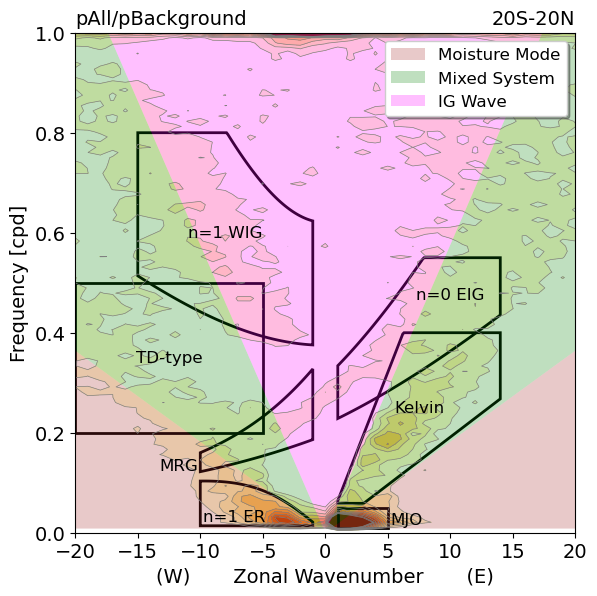

In [12]:
figx = 7.0
figy = 8.0

fig = plt.figure(figsize=(figx, figy))

levels = np.arange(2.0, 4.2, 0.2)
cmap = "YlOrBr"
lw = 2.0
fontsize = 14.0

ax = fig.add_axes([1.0 / figx, 2.0 / figy, 5.0 / figx, 5.0 / figy])
plot = ax.contourf(k, frq, pAll, levels=levels, cmap=cmap, extend="max")
plot_contour = ax.contour(k, frq, pAll, levels=levels, colors="grey", linewidths=0.5)

poly_MJO = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=5.0, frq_min=1.0 / 100.0, frq_max=1.0 / 20.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw)
poly_Kelvin = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=14.0, frq_min=1.0 / 17.0, frq_max=1.0 / 2.5, h_min=8.0, h_max=90.0, wave="Kelvin"), closed=True, ec="black", fc="none", lw=lw)
poly_ER = Polygon(filter_mode.stsa.calc_wave_region(k_min=-10.0, k_max=-1.0, frq_min=1.0 / 72.0, frq_max=1.0 / 9.0, h_min=None, h_max=90.0, wave="ER"), closed=True, ec="black", fc="none", lw=lw)
poly_MRG = Polygon(filter_mode.stsa.calc_wave_region(k_min=-10.0, k_max=-1.0, frq_min=1.0 / 10.0, frq_max=1.0 / 3.0, h_min=8.0, h_max=90.0, wave="MRG"), closed=True, ec="black", fc="none", lw=lw)
poly_EIG = Polygon(filter_mode.stsa.calc_wave_region(k_min=1.0, k_max=14.0, frq_min=1.0 / 5.0, frq_max=0.55, h_min=12.0, h_max=50.0, wave="MRG"), closed=True, ec="black", fc="none", lw=lw)
poly_WIG = Polygon(filter_mode.stsa.calc_wave_region(k_min=-15.0, k_max=-1.0, frq_min=1.0 / 3.0, frq_max=0.8, h_min=12.0, h_max=90.0, wave="IG1"), closed=True, ec="black", fc="none", lw=lw)
poly_TD = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=-5.0, frq_min=1.0 / 5.0, frq_max=1.0 / 2.0, h_min=None, h_max=None, wave=None), closed=True, ec="black", fc="none", lw=lw)

ax.add_patch(poly_MJO)
ax.add_patch(poly_Kelvin)
ax.add_patch(poly_ER)
ax.add_patch(poly_MRG)
ax.add_patch(poly_EIG)
ax.add_patch(poly_WIG)
ax.add_patch(poly_TD)

ax.text(5.2, 1.0 / 40.0, "MJO", fontsize=12.0, ha="left", va="center")
ax.text(-9.8, 2.0 / 63.0, "n=1 ER", fontsize=12.0, ha="left", va="center")
ax.text(-10.2, 1.0 / 7.5, "MRG", fontsize=12.0, ha="right", va="center")
ax.text(7.5, 0.25, "Kelvin", fontsize=12.0, ha="center", va="center")
ax.text(10.0, 0.475, "n=0 EIG", fontsize=12.0, ha="center", va="center")
ax.text(-12.5, 0.35, "TD-type", fontsize=12.0, ha="center", va="center")
ax.text(-11.0, 0.6, "n=1 WIG", fontsize=12.0, ha="left", va="center")

poly_1 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=20.0, frq_min=1.0 / 120.0, frq_max=4.0, h_min=None, h_max=None, wave="Moisture Mode"), closed=True, alpha=0.25, ec="none", fc="brown")
poly_2 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=20.0, frq_min=1.0 / 120.0, frq_max=4.0, h_min=None, h_max=None, wave="Mixed System"), closed=True, alpha=0.25, ec="none", fc="green")
poly_3 = Polygon(filter_mode.stsa.calc_wave_region(k_min=-20.0, k_max=20.0, frq_min=1.0 / 120.0, frq_max=4.0, h_min=None, h_max=None, wave="IG Wave"), closed=True, alpha=0.25, ec="none", fc="magenta")

ax.add_patch(poly_1)
ax.add_patch(poly_2)
ax.add_patch(poly_3)

legend_elements = [Patch(alpha=0.25, ec="none", fc="brown", label="Moisture Mode"), Patch(alpha=0.25, ec="none", fc="green", label="Mixed System"), Patch(alpha=0.25, ec="none", fc="magenta", label="IG Wave")]

ax.set_title("pAll/pBackground", loc="left", fontsize=fontsize)
ax.set_title("20S-20N", loc="right", fontsize=fontsize)
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(0.0, 1.0)
ax.set_xticks(np.arange(-20.0, 25.0, 5.0))
ax.set_yticks(np.arange(0.0, 1.2, 0.2))
ax.tick_params(labelsize=fontsize)
ax.set_xlabel("(W)       Zonal Wavenumber       (E)", fontsize=fontsize)
ax.set_ylabel("Frequency [cpd]", fontsize=fontsize)
ax.legend(handles=legend_elements, loc="upper right", fontsize=12.0, shadow=True)

fig.savefig(fname="/home/565/mr4682/trop-wx-sys-characs/plots/stsa_all_isccp_olr.png", bbox_inches="tight")

plt.show()